In [24]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import create_grid

enc = 'utf-8'

random.seed(0)
np.random.seed(0)

In [25]:
germany_nuts3 = gpd.read_file(f"../data/DE_NUTS3.shp",  encoding=enc)

In [26]:
germany_nuts3

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,DE21A,DE,Erding,Erding,4.0,3,3,Germany,"POLYGON ((12.01712 48.43068, 12.02210 48.42585..."
1,DE94E,DE,"Osnabrück, Landkreis","Osnabrück, Landkreis",4.0,2,3,Germany,"POLYGON ((8.01815 52.68391, 8.03442 52.67338, ..."
2,DE94F,DE,Vechta,Vechta,4.0,2,3,Germany,"POLYGON ((8.45928 52.80106, 8.45051 52.78637, ..."
3,DE94G,DE,Wesermarsch,Wesermarsch,4.0,2,1,Germany,"POLYGON ((8.55490 53.52513, 8.54756 53.52128, ..."
4,DEA59,DE,Olpe,Olpe,2.0,2,3,Germany,"POLYGON ((8.23880 51.10434, 8.22833 51.09961, ..."
...,...,...,...,...,...,...,...,...,...
396,DE94H,DE,Wittmund,Wittmund,4.0,3,1,Germany,"MULTIPOLYGON (((7.80990 53.70766, 7.83333 53.6..."
397,DEA11,DE,"Düsseldorf, Kreisfreie Stadt","Düsseldorf, Kreisfreie Stadt",4.0,1,3,Germany,"POLYGON ((6.85605 51.12619, 6.84978 51.13341, ..."
398,DEG0L,DE,Greiz,Greiz,4.0,2,3,Germany,"POLYGON ((12.22417 50.94293, 12.22471 50.93943..."
399,DEG0M,DE,Altenburger Land,Altenburger Land,4.0,2,3,Germany,"POLYGON ((12.61735 50.98079, 12.62094 50.97590..."


In [27]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, germany_nuts3, col_municipal='NUTS_NAME', dimension=4)

e:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU\Germany\notebooks\../../../Modules\preprocessing_utils.py:43: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will 

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\plotting.py:693: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


<AxesSubplot:>

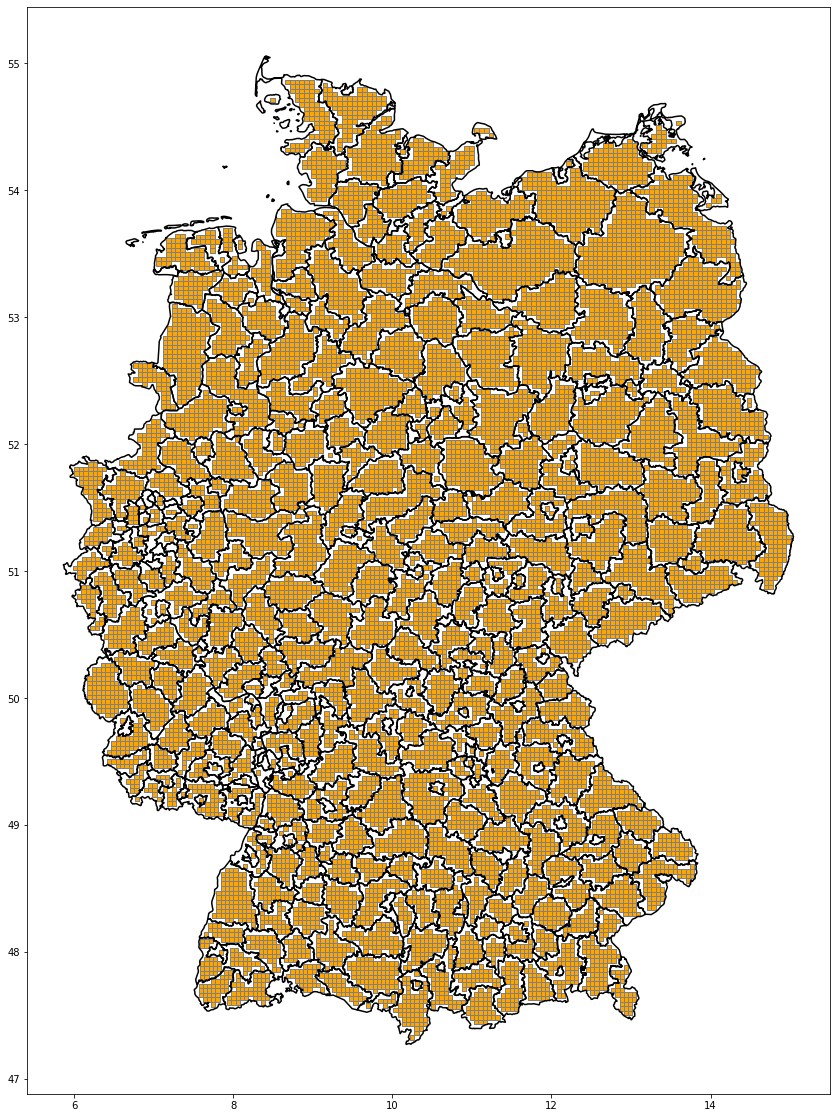

In [28]:
ax = empty_gdf.plot(figsize=(20, 20), cmap='jet', color='blue', lw=1)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')
germany_nuts3.plot(facecolor="none", edgecolor='black', ax=ax, lw=1.5)

In [32]:
df_grid.rename(columns={"NAME": "NUTS_NAME"}, inplace = True)

In [34]:
df_grid_de3 = pd.merge(df_grid, germany_nuts3.drop(columns=('geometry')), how='left', on=['NUTS_NAME'])

In [35]:
df_grid_de3

,geometry,centers,NUTS_NAME,x,y,NUTS_ID,CNTR_CODE,NAME_LATN,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME
0,"POLYGON ((11.83993 48.24947, 11.83993 48.28541...",POINT (11.813009466311193 48.2674408412015),Erding,11.81301,48.26744,DE21A,DE,Erding,4.0,3,3,Germany
1,"POLYGON ((11.83993 48.28541, 11.83993 48.32134...",POINT (11.813009466311193 48.303374224401935),Erding,11.81301,48.30337,DE21A,DE,Erding,4.0,3,3,Germany
2,"POLYGON ((11.83993 48.32134, 11.83993 48.35727...",POINT (11.813009466311193 48.339307607602365),Erding,11.81301,48.33931,DE21A,DE,Erding,4.0,3,3,Germany
3,"POLYGON ((11.89378 48.21354, 11.89378 48.24947...",POINT (11.866859110518654 48.231507458001076),Erding,11.86686,48.23151,DE21A,DE,Erding,4.0,3,3,Germany
4,"POLYGON ((11.89378 48.24947, 11.89378 48.28541...",POINT (11.866859110518654 48.2674408412015),Erding,11.86686,48.26744,DE21A,DE,Erding,4.0,3,3,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
13576,"POLYGON ((12.49223 51.02604, 12.49223 51.06197...",POINT (12.463798093842898 51.044005990802795),Altenburger Land,12.46380,51.04401,DEG0M,DE,Altenburger Land,4.0,2,3,Germany
13577,"POLYGON ((12.54910 50.91824, 12.54910 50.95417...",POINT (12.520664781363543 50.936205841201506),Altenburger Land,12.52066,50.93621,DEG0M,DE,Altenburger Land,4.0,2,3,Germany
13578,"POLYGON ((12.54910 50.95417, 12.54910 50.99011...",POINT (12.520664781363543 50.97213922440194),Altenburger Land,12.52066,50.97214,DEG0M,DE,Altenburger Land,4.0,2,3,Germany
13579,"POLYGON ((12.60596 50.91824, 12.60596 50.95417...",POINT (12.577531468884189 50.936205841201506),Altenburger Land,12.57753,50.93621,DEG0M,DE,Altenburger Land,4.0,2,3,Germany


In [36]:
df_grid_de3.drop(columns=('centers')).to_file('../data/DE_Grid_NUTS3_4x4.shp', encoding = 'utf-8')

In [20]:
np.sort(df_grid_de3.NUTS_ID.unique())

array(['DE11', 'DE12', 'DE13', 'DE14', 'DE21', 'DE22', 'DE23', 'DE24',
       'DE25', 'DE26', 'DE27', 'DE30', 'DE40', 'DE50', 'DE60', 'DE71',
       'DE72', 'DE73', 'DE80', 'DE91', 'DE92', 'DE93', 'DE94', 'DEA1',
       'DEA2', 'DEA3', 'DEA4', 'DEA5', 'DEB1', 'DEB2', 'DEB3', 'DEC0',
       'DED2', 'DED4', 'DED5', 'DEE0', 'DEF0', 'DEG0'], dtype=object)